Physics-Informed Neural Network (PINN) with L-BFGS Optimization for the 1D Heat Equation (Validated via FDM)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from IPython import display


torch.manual_seed(128)

In [33]:
# set num of points for each condition
n_int = 2000 # interior points
n_sb = 1000  #spatial boundary points
n_tb = 400 # temporal boundary points
lamda = 10 # weight of boundary loss

In [34]:
# NN for predition

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2,64),
            nn.Tanh(),
            nn.Linear(64,128),
            nn.Tanh(),
            nn.Linear(128,64),
            nn.Tanh(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        out = self.network(x)
        return out

In [35]:
#  Data Generation 

T_max = 60
Length_of_bar = 1

# Domain limits [t_min, t_max] and [x_min, x_max]
domain_extrema = torch.tensor([[0, T_max], [0, Length_of_bar]])

# Initialize Sobol Engine (2D since (t,x)); creates uniform data
soboleng = torch.quasirandom.SobolEngine(dimension=2)

def convert(raw, extrema):
    """Linearly transforms a tensor from [0,1] to [min, max] since Sobol creates data in range [0,1]"""
    return raw * (extrema[:, 1] - extrema[:, 0]) + extrema[:, 0]


""" Here we are creating input and output for each loss term """

# Create Interior Data
# Sample points inside the domain where the PDE (u_t = u_xx) is enforced
input_int = convert(soboleng.draw(n_int), domain_extrema)
output_int = torch.zeros((n_int, 1)) # The target for the PDE residual is 0


#  Create data at time t= 0
input_tb = convert(soboleng.draw(n_tb), domain_extrema)
input_tb[:, 0] = 0  # Force time to be 0
output_tb = torch.zeros((n_tb, 1))  #  The target is a tensor of zeros since the rod starts cold everywhere


# Create Spatial Boundary Data 
input_raw = convert(soboleng.draw(n_sb), domain_extrema)

# Left Boundary at x = 0 (Held at 0)
input_sb_0 = input_raw.clone()
input_sb_0[:, 1] = 0
output_sb_0 = torch.zeros((n_sb, 1)) # Ice condition:0

# Right Boundary at x = length of bar (Held at 1)
input_sb_L = input_raw.clone()
input_sb_L[:, 1] = Length_of_bar
output_sb_L = torch.ones((n_sb, 1)) # heat condition:1

# concat both boundary inputs and boundary targets together vertically
input_sb = torch.cat([input_sb_0, input_sb_L], 0)
output_sb = torch.cat([output_sb_0, output_sb_L], 0) 


#  Create DataLoaders
train_loader_int = DataLoader(TensorDataset(input_int, output_int), batch_size=n_int, shuffle=False) # full data in each batch since PINNS use complete data before updating weights
train_loader_tb = DataLoader(TensorDataset(input_tb, output_tb), batch_size=n_tb, shuffle=False)
train_loader_sb = DataLoader(TensorDataset(input_sb, output_sb), batch_size=2*n_sb, shuffle=False)

print(f"Data Prepared for Asymmetric Problem:")
print(f"Interior ({len(input_int)}), Temporal ({len(input_tb)}), Spatial ({len(input_sb)})")

Data Prepared for Asymmetric Problem:
Interior (2000), Temporal (400), Spatial (2000)


In [36]:


def compute_loss(model, input_int, input_sb, target_sb, input_tb, target_tb, lamda, criterion):
    """
    Custom Loss Function for 1D Heat Equation PINN (Asymmetric Dirichlet Problem)
    
    model: The NeuralNet model accepting 2D input (t, x)
    input_int: Points inside the rod (for PDE residual)
    input_sb: Points at the ends x=0, x=length (for Spatial Boundary)
    target_sb: Expected temperature values (0 at x=0, 1 at x=1)
    input_tb: Points at t=0 (for Initial Condition)
    target_tb: Expected initial values (0 everywhere on bar)
    """
    
    # Interior PDE Loss 
    # Enable gradient tracking for input coordinates to compute derivatives
    input_int.requires_grad = True
    u = model(input_int)
    
    # Calculate first derivatives: du/dt and du/dx
    # u.sum() converts the batch vector into a scalar so autograd can compute gradients
    grads = torch.autograd.grad(u.sum(), input_int, create_graph=True)[0]
    u_t = grads[:, 0]
    u_x = grads[:, 1]
    
    # Calculate second spatial derivative: d^2u / dx^2
    u_xx = torch.autograd.grad(u_x.sum(), input_int, create_graph=True)[0][:, 1]  #ex:(100,2) , 2 --> (t,x)
    
    # The PDE residual for the heat equation: u_t - u_xx = 0
    r_int = (u_t - u_xx).reshape(-1, 1)
    
    # Compare residual against a target matrix of zeros
    loss_int = criterion(r_int, torch.zeros_like(r_int))

    #  Spatial Boundary Loss 

    # Model evaluates the boundary inputs (ends of the rod over time)
    u_sb_pred = model(input_sb)

    # Compares predictions with target_sb
    loss_sb = criterion(u_sb_pred, target_sb)

    # Intial Time condition loss

    # Model evaluates the whole rod at t=0
    u_tb_pred = model(input_tb)

    # Compares predictions with target_tb (which contains 0s everywhere)
    loss_tb = criterion(u_tb_pred, target_tb)

    #  Total Weighted Loss 

    total_loss = loss_int + lamda * (loss_sb + loss_tb)
    
    return total_loss

In [37]:
model = Model()
criterion = nn.MSELoss()
# Initialize L-BFGS Optimizer
optimizer = optim.LBFGS(
    model.parameters(), 
    lr=1.0, 
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
)
#optimizer = optim.Adam(model.parameters(),lr = 0.001)
epochs = 200

L-BFGS Training Loop Successfully Finished! Final Combined Evaluation Loss: 1.177717e-04


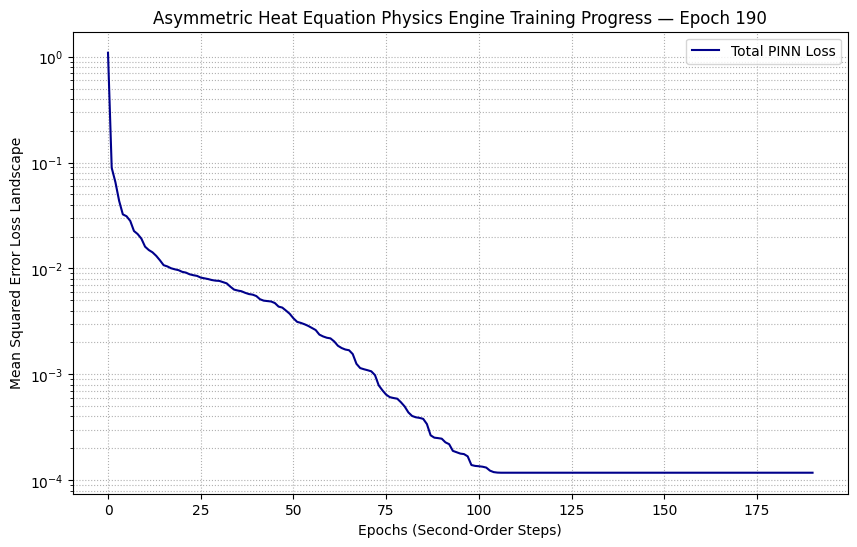

In [38]:
loss_history_total = []
plt.figure(figsize=(10, 6))

# loss tracking 

current_loss = torch.tensor(0.0)

for epoch in range(epochs):
    model.train()
    
    for (batch_int, _), (batch_tb, target_tb), (batch_sb, target_sb) in zip(train_loader_int, train_loader_tb, train_loader_sb):
        
        # Define closure function (required by L-BFGS)
        def closure():
            optimizer.zero_grad()
            global current_loss
            current_loss = compute_loss(model, batch_int, batch_sb, target_sb, batch_tb, target_tb, lamda, criterion)
            current_loss.backward()
            return current_loss
            
        optimizer.step(closure)
        
    loss_history_total.append(current_loss.item())

    # Update chart every 10 L-BFGS iterations
    if epoch % 10 == 0:
        display.clear_output(wait=True)
        plt.clf()
        
        plt.plot(loss_history_total, label='Total PINN Loss', color='darkblue', linewidth=1.5)
        plt.yscale('log')
        plt.xlabel('Epochs (Second-Order Steps)')
        plt.ylabel('Mean Squared Error Loss Landscape')
        plt.title(f'Asymmetric Heat Equation Physics Engine Training Progress — Epoch {epoch}')
        plt.legend()
        plt.grid(True, which="both", ls=":")
        
        display.display(plt.gcf())

# Final clear and visual display summary
display.clear_output(wait=True)
print(f"L-BFGS Training Loop Successfully Finished! Final Combined Evaluation Loss: {loss_history_total[-1]:.6e}")
plt.show()

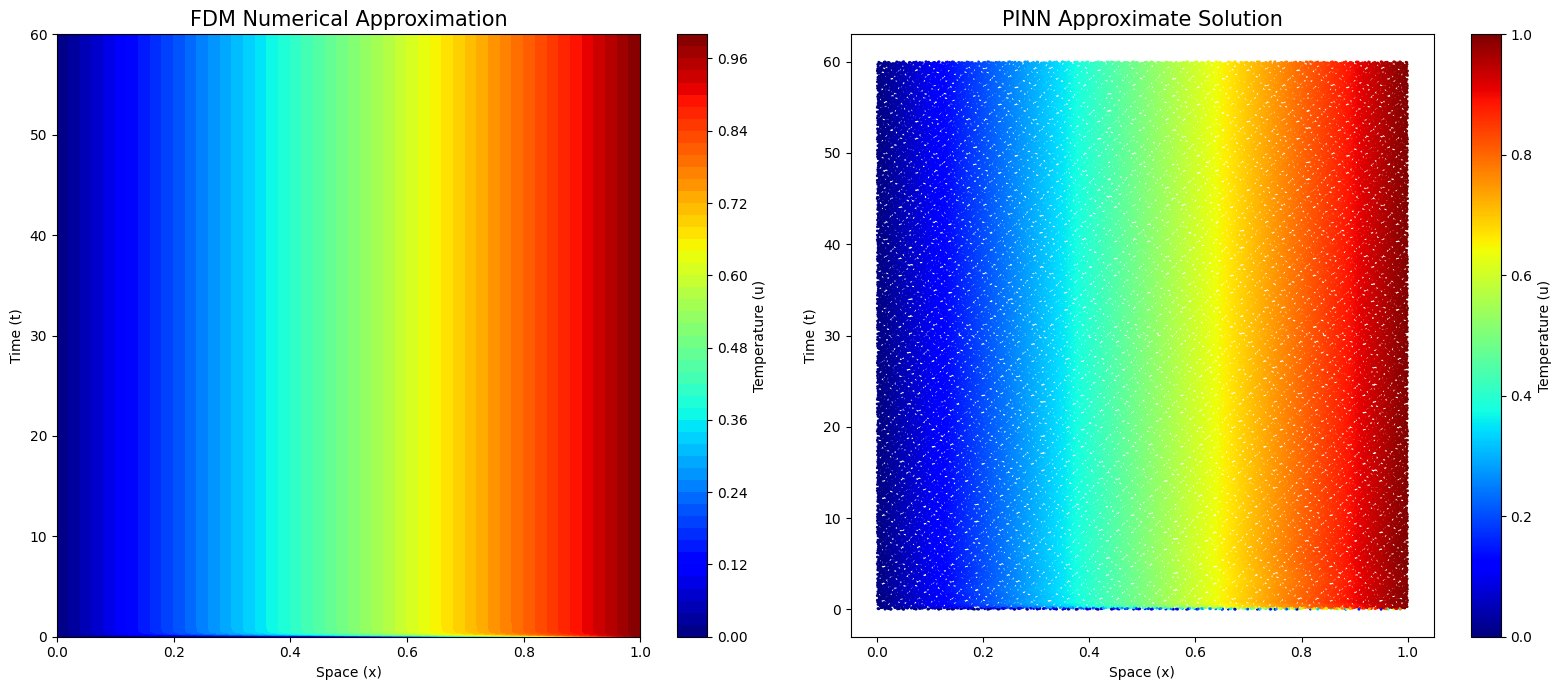

L2 Relative Difference (PINN vs FDM): 0.79%


In [ ]:

def run_fdm_vs_pinn_comparison(model, convert_func, sobol_eng, domain_extrema, Length_of_bar=1.0, T_max=60.0):
    """
    Computes a Finite Difference Method solution, evaluates trained PINN,
    plots them side-by-side, and outputs the quantitative L2 relative difference.
    """

    #Finite Difference Method (FDM) Solver

    Nx = 51   # Number of spatial coordinates
    dx = Length_of_bar / (Nx - 1)
    x_fdm = np.linspace(0, Length_of_bar, Nx)
    
    # stable if dt <= 0.5 * dx^2
    dx2 = dx ** 2
    dt = 0.4 * dx2  # ensures that method is stable 
    Nt = int(T_max / dt) + 1
    t_fdm = np.linspace(0, T_max, Nt)
    
    # Initialize solution matrix (Rows = Time, Cols = Space)
    u_fdm_grid = np.zeros((Nt, Nx))
    u_fdm_grid[0, :] = 0.0    # Completely cold rod initial state
    u_fdm_grid[:, 0] = 0.0     # Left boundary temperature
    u_fdm_grid[:, -1] = 1.0    # Right boundary temperature
    
    # Forward Euler
    r = dt / dx2
    for j in range(0, Nt - 1):
        for i in range(1, Nx - 1):
            u_fdm_grid[j+1, i] = u_fdm_grid[j, i] + r * (u_fdm_grid[j, i+1] - 2*u_fdm_grid[j, i] + u_fdm_grid[j, i-1])

    # Testing Grid Evaluation for PINN
    n_test = 100000
    raw_test_data = sobol_eng.draw(n_test)
    test_inputs = convert_func(raw_test_data, domain_extrema)

    device = next(model.parameters()).device
    test_inputs = test_inputs.to(device)

    model.eval()
    with torch.no_grad():
        u_pinn_pred = model(test_inputs).reshape(-1).cpu().numpy()
        
    x_pinn = test_inputs[:, 1].cpu().numpy()
    t_pinn = test_inputs[:, 0].cpu().numpy()

    # Create Side-by-Side Visualization

    plt.ion() # Forces interactive drawing updates in Jupyter
    fig, ax = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

    X_fdm, T_fdm = np.meshgrid(x_fdm, t_fdm)
    
    # Plot 1: FDM Contour
    sc1 = ax[0].contourf(X_fdm, T_fdm, u_fdm_grid, levels=50, cmap='jet')
    ax[0].set_title("FDM Numerical Approximation", fontsize=15)
    ax[0].set_xlabel("Space (x)")
    ax[0].set_ylabel("Time (t)")
    fig.colorbar(sc1, ax=ax[0], label='Temperature (u)')

    # Plot 2: PINN Scatter
    sc2 = ax[1].scatter(x_pinn, t_pinn, c=u_pinn_pred, cmap='jet', s=1, vmin=0.0, vmax=1.0)
    ax[1].set_title("PINN Approximate Solution", fontsize=15)
    ax[1].set_xlabel("Space (x)")
    ax[1].set_ylabel("Time (t)")
    fig.colorbar(sc2, ax=ax[1], label='Temperature (u)')

    plt.tight_layout()
    fig.canvas.draw()
    plt.show()

    # L2 Relative Error
    X_flat = X_fdm.flatten()
    T_flat = T_fdm.flatten()
    fdm_flat = u_fdm_grid.flatten()
    
    pinn_eval_points = torch.tensor(np.stack([T_flat, X_flat], axis=1), dtype=torch.float32).to(device) #creates cordinates in format(t,x) after stacking both dimensions
    
    num_points = pinn_eval_points.shape[0]
    batch_size = 500000
    u_pinn_at_fdm_nodes_list = []
    
    with torch.no_grad():
        for i in range(0, num_points, batch_size):
            batch_inputs = pinn_eval_points[i : i + batch_size]
            batch_preds = model(batch_inputs).reshape(-1).cpu().numpy()
            u_pinn_at_fdm_nodes_list.append(batch_preds)
            
    u_pinn_at_fdm_nodes = np.concatenate(u_pinn_at_fdm_nodes_list)
        
    l2_pinn_vs_fdm = np.linalg.norm(fdm_flat - u_pinn_at_fdm_nodes) / np.linalg.norm(fdm_flat + 1e-8)
    
   
    print(f"L2 Relative Difference (PINN vs FDM): {l2_pinn_vs_fdm * 100:.2f}%")
   

run_fdm_vs_pinn_comparison(model, convert, soboleng, domain_extrema, Length_of_bar=Length_of_bar, T_max=T_max)